In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_json("..\data\historical_data.json")

print(df.shape)
df.head()

(12336, 14)


,timestamp,temperature(°C),humidity(%),precipitation(mm),pressure(hPa),wind_speed(km/h),wind_dir,cloud_cover(%),boundary_layer_h(meters),pm25,pm10,no2,o3,aqi
0,2025-01-01 00:00:00,14.9,63,0.0,1015.7,11.0,360,2,150.0,34.2,34.5,14.5,58,73
1,2025-01-01 01:00:00,14.4,65,0.0,1015.2,11.4,5,10,150.0,34.5,34.8,11.3,62,72
2,2025-01-01 02:00:00,14.0,65,0.0,1014.8,12.1,7,16,165.0,35.4,35.7,8.6,65,71
3,2025-01-01 03:00:00,13.6,66,0.0,1014.7,12.7,7,84,185.0,37.1,37.5,6.8,67,70
4,2025-01-01 04:00:00,13.2,66,0.0,1014.5,13.4,8,100,200.0,39.5,39.9,5.5,68,69


In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12336 entries, 0 to 12335
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 12336 non-null  datetime64[ns]
 1   temperature(°C)           12336 non-null  float64       
 2   humidity(%)               12336 non-null  int64         
 3   precipitation(mm)         12336 non-null  float64       
 4   pressure(hPa)             12336 non-null  float64       
 5   wind_speed(km/h)          12336 non-null  float64       
 6   wind_dir                  12336 non-null  int64         
 7   cloud_cover(%)            12336 non-null  int64         
 8   boundary_layer_h(meters)  12336 non-null  float64       
 9   pm25                      12336 non-null  float64       
 10  pm10                      12336 non-null  float64       
 11  no2                       12336 non-null  float64       
 12  o3                

,timestamp,temperature(°C),humidity(%),precipitation(mm),pressure(hPa),wind_speed(km/h),wind_dir,cloud_cover(%),boundary_layer_h(meters),pm25,pm10,no2,o3,aqi
count,12336,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000,12336.000000
mean,2025-09-14 23:30:00,27.025851,51.419261,0.019358,1005.169634,11.426678,195.919747,25.009809,661.732733,28.094780,53.074546,8.869609,83.126378,62.651427
min,2025-01-01 00:00:00,7.300000,4.000000,0.000000,987.000000,0.000000,1.000000,0.000000,10.000000,3.500000,4.300000,0.000000,14.000000,17.000000
25%,2025-05-09 11:45:00,22.100000,33.000000,0.000000,999.400000,7.100000,183.000000,0.000000,155.000000,17.700000,32.000000,3.100000,55.000000,54.000000
50%,2025-09-14 23:30:00,27.500000,51.000000,0.000000,1005.400000,11.300000,224.000000,0.000000,440.000000,24.300000,45.900000,6.400000,76.000000,64.000000
75%,2026-01-21 11:15:00,32.100000,70.000000,0.000000,1011.200000,15.600000,244.000000,44.000000,895.000000,34.600000,65.200000,11.200000,110.000000,72.000000
max,2026-05-29 23:00:00,46.300000,99.000000,12.500000,1022.300000,29.500000,360.000000,100.000000,5585.000000,105.500000,560.700000,57.600000,182.000000,128.000000
std,NaN,7.340924,22.540128,0.337303,7.156350,5.501980,101.222314,38.654148,699.595314,14.922995,33.125370,8.221168,34.094028,16.274423


# Checking for duplicates

In [4]:
dupes = df.duplicated(subset=["timestamp"]).sum()
print(f"Duplicate timestamps: {dupes}")

Duplicate timestamps: 0


- Hence ther are not duplicates in data

# Checking Missing Values

In [5]:
missing = (df.isnull().sum() / len(df) * 100).round(1)
print(missing[missing > 0])


Series([], dtype: float64)


Hence No missing values

# Checking for outliers

In [6]:
# Physically valid ranges for Hyderabad, Sindh
checks = {
    "temperature(°C)":          (-5,  50),
    "humidity(%)":              (0,   100),
    "precipitation(mm)":        (0,   50),
    "pressure(hPa)":            (950, 1050),
    "wind_speed(km/h)":         (0,   120),
    "wind_dir":                 (0,   360),
    "cloud_cover(%)":           (0,   100),
    "boundary_layer_h(meters)": (0,   6000),
    "pm25":                     (0,   500),
    "pm10":                     (0,   600),
    "no2":                      (0,   300),
    "o3":                       (0,   400),
    "aqi":                      (0,   500),
}

print("Outlier Check:")
all_clean = True
for col, (low, high) in checks.items():
    if col not in df.columns:
        continue
    bad = df[(df[col] < low) | (df[col] > high)]
    if len(bad) > 0:
        all_clean = False
        print(f" {col}: {len(bad)} bad values — min={df[col].min()}, max={df[col].max()}")
    else:
        print(f" {col}: OK  (min={df[col].min()}, max={df[col].max()})")

if all_clean:
    print("\nNo outliers found")

Outlier Check:
 temperature(°C): OK  (min=7.3, max=46.3)
 humidity(%): OK  (min=4, max=99)
 precipitation(mm): OK  (min=0.0, max=12.5)
 pressure(hPa): OK  (min=987.0, max=1022.3)
 wind_speed(km/h): OK  (min=0.0, max=29.5)
 wind_dir: OK  (min=1, max=360)
 cloud_cover(%): OK  (min=0, max=100)
 boundary_layer_h(meters): OK  (min=10.0, max=5585.0)
 pm25: OK  (min=3.5, max=105.5)
 pm10: OK  (min=4.3, max=560.7)
 no2: OK  (min=0.0, max=57.6)
 o3: OK  (min=14, max=182)
 aqi: OK  (min=17, max=128)

No outliers found


# Checking AQI Distribution

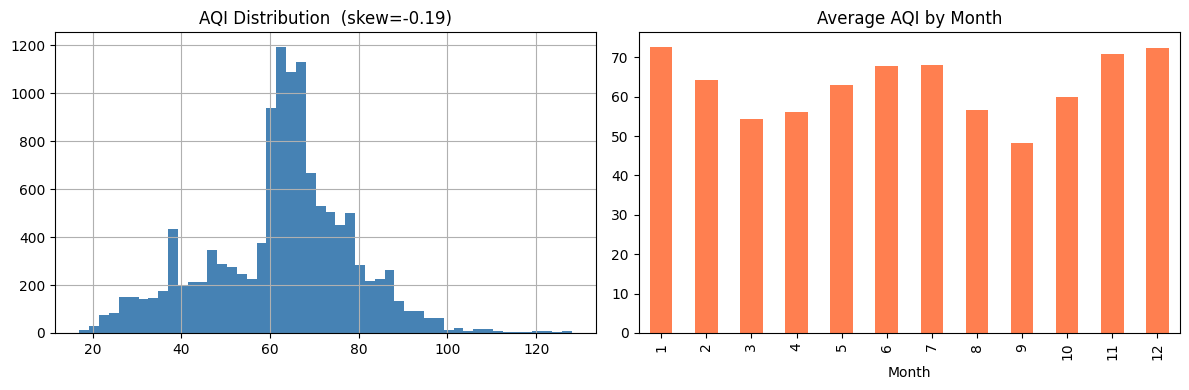

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["aqi"].hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title(f"AQI Distribution  (skew={df['aqi'].skew():.2f})")

df.groupby(df["timestamp"].dt.month)["aqi"].mean().plot(
    kind="bar", ax=axes[1], color="coral"
)
axes[1].set_title("Average AQI by Month")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.savefig("..\plots\eda\ aqi_distribution.png")
plt.show()

skew (-0.26), almost perfectly balanced, very slight lean toward higher values
  
1. Understanding from data:
 - Higher AQI (more pollution):
     - Months 1, 6, 7, 11, 12  
Likely: Winter smog Less wind → pollution trapped

  - Lower AQI (cleaner air):
     - Months 3, 4, 8, 9  
Likely: Rain or better air circulation

Months have correlation with AQI

# Time Patterns
For checking if hours of the day, day of the week or months of the year have any impact on aqi

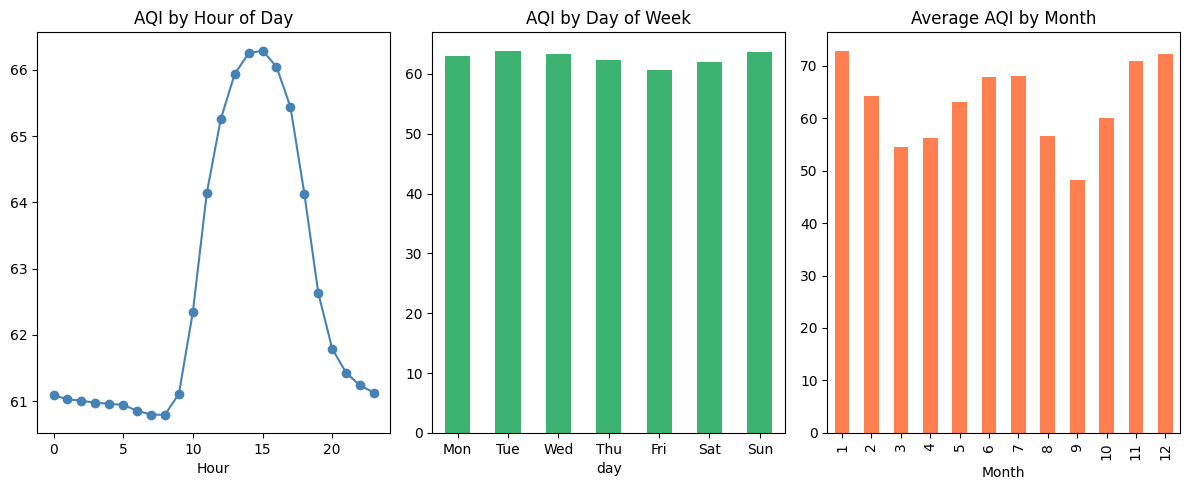

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

df.groupby(df["timestamp"].dt.hour)["aqi"].mean().plot(
    ax=axes[0], marker="o", color="steelblue"
)
axes[0].set_title("AQI by Hour of Day")
axes[0].set_xlabel("Hour")

days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
df.groupby(df["timestamp"].dt.dayofweek)["aqi"].mean().plot(
    kind="bar", ax=axes[1], color="mediumseagreen"
)
axes[1].set_xticklabels(days, rotation=0)
axes[1].set_title("AQI by Day of Week")
axes[1].set_xlabel("day")

df.groupby(df["timestamp"].dt.month)["aqi"].mean().plot(
    kind="bar", ax=axes[2], color="coral"
)
axes[2].set_title("Average AQI by Month")
axes[2].set_xlabel("Month")


plt.tight_layout()
plt.savefig("..\plots\eda\ time_patterns.png")
plt.show()

- Since at certain hours (4 to 8), there are lower aqi levels and at hours (13 to 16) there is a spike in aqi, hours day of the day can also be used to predict aqi

- There is no significant effect of the day of the week on aqi

- Higher AQI (more pollution):
     - Months 1, 6, 7, 11, 12  
Likely: Winter smog Less wind → pollution trapped

- Lower AQI (cleaner air):
     - Months 3, 4, 8, 9  
Likely: Rain or better air circulation

Months have impact on AQI


# Checking Feature Correlation with AQI: What drives aqi

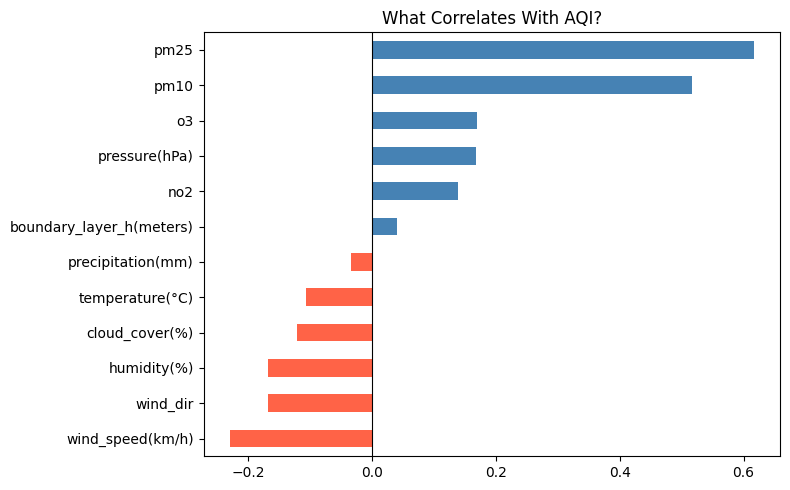

pm25                        0.616472
pm10                        0.517212
wind_speed(km/h)            0.229931
o3                          0.169489
wind_dir                    0.168113
humidity(%)                 0.167734
pressure(hPa)               0.167496
no2                         0.138930
cloud_cover(%)              0.122175
temperature(°C)             0.107422
boundary_layer_h(meters)    0.039674
precipitation(mm)           0.033877
Name: aqi, dtype: float64


In [8]:
features = ["temperature(°C)", "humidity(%)",  "precipitation(mm)", "boundary_layer_h(meters)", 
       "pressure(hPa)","wind_speed(km/h)","wind_dir","cloud_cover(%)" ,"pm25", "pm10", "no2","o3"]

corr = df[features + ["aqi"]].corr()["aqi"].drop("aqi").sort_values()

corr.plot(kind="barh", figsize=(8, 5), color=[
    "tomato" if x < 0 else "steelblue" for x in corr
])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("What Correlates With AQI?")
plt.tight_layout()
plt.savefig("correlation.png")
plt.show()

print(corr.abs().sort_values(ascending=False))

**Understanding:** 
- Certain factors such as pm25, pm10, pressure are strong contributors to the Higher AQI levels (Postive Correlation)
- Factors like wind speed, humidity are strong contributors to lower AQI Levels (Negative Correlation)
- Factors like o3, no2 , wind direction, cloud cover, pressure, temeprature, also mildly contribute to the AQI levels
- boundary_layer_h, and precipitation have the lowest contribution (Not signification - ignorable)

# Checking If Past AQI Predicts Future AQI

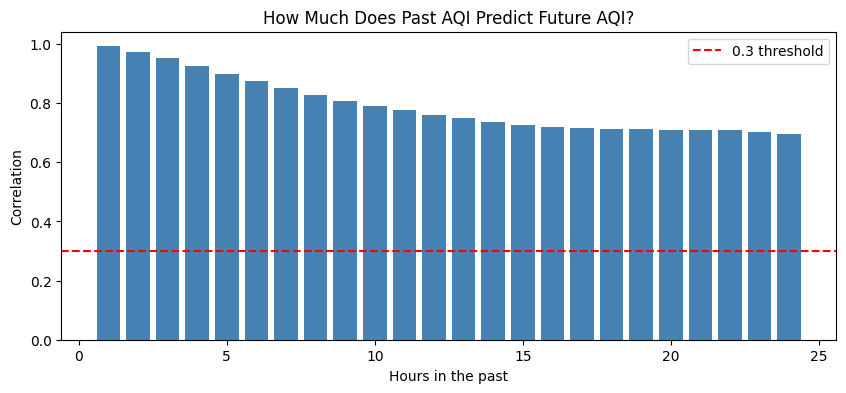

Useful lags (correlation > 0.3):
  1h ago: 0.99
  2h ago: 0.97
  3h ago: 0.95
  4h ago: 0.93
  5h ago: 0.90
  6h ago: 0.87
  7h ago: 0.85
  8h ago: 0.83
  9h ago: 0.81
  10h ago: 0.79
  11h ago: 0.78
  12h ago: 0.76
  13h ago: 0.75
  14h ago: 0.74
  15h ago: 0.73
  16h ago: 0.72
  17h ago: 0.71
  18h ago: 0.71
  19h ago: 0.71
  20h ago: 0.71
  21h ago: 0.71
  22h ago: 0.71
  23h ago: 0.70
  24h ago: 0.69


In [9]:
lags = range(1, 25)
lag_corrs = [df["aqi"].autocorr(lag) for lag in lags]

plt.figure(figsize=(10, 4))
plt.bar(lags, lag_corrs, color="steelblue")
plt.axhline(0.3, color="red", linestyle="--", label="0.3 threshold")
plt.title("How Much Does Past AQI Predict Future AQI?")
plt.xlabel("Hours in the past")
plt.ylabel("Correlation")
plt.legend()
plt.savefig("past_hours_correlation.png")
plt.show()

print("Useful lags (correlation > 0.3):")
for lag, c in zip(lags, lag_corrs):
    if abs(c) > 0.3:
        print(f"  {lag}h ago: {c:.2f}")

1. What autocorrelation means:
- This asks: "If I know AQI right now, how well can I predict AQI X hours from now?"
 
 Even 24 hours back still has 0.71 correlation. This means AQI in Hyderabad changes slowly and predictably. it doesn't jump randomly. That makes it very forecastable.

# Removing insignificant Features
( "precipitation(mm)", "boundary_layer_h(meters)")

In [10]:
insignificant_features = [ "precipitation(mm)", "boundary_layer_h(meters)"]

print("Before : ", df.shape)

df = df.drop(columns=insignificant_features)

print("After : ", df.shape)

df.to_json("../data/historical_data_clean.json", index=False, orient='records', date_format="iso", indent=2)

Before :  (12336, 14)
After :  (12336, 12)


# Feature to include by understanding the Data using eda:

FEATURES =   
 - Pollutants — strongest signal
    - "pm25", "pm10", "no2", "o3",

- Weather — meaningful negative correlations
    - "wind_speed", "humidity", "cloud_cover", "wind_dir",

-  Borderline — keep for now
    - "temperature", "pressure",

- Lag features — from autocorrelation results
    - "aqi_lag_1h", "aqi_lag_6h", "aqi_lag_12h", "aqi_lag_24h",

- Time features
     - "hour", "month"

-  Dropped — too weak to help
   -  precipitation, boundary_layer_h